<a href="https://sigmoidal.ai/en/">
  <img src="https://raw.githubusercontent.com/carlosfab/blog-sigmoidal/main/_assets/logo_sigmoidal.png" alt="Sigmoidal" width="300">
</a>

# DETR: Object Detection with Transformers

**Author:** Carlos Melo — [sigmoidal.ai](https://sigmoidal.ai/en/)

This notebook provides a reproducible view of DETR's central mechanisms: **set prediction**, **2D positional encoding**, **object queries**, **bipartite matching**, and the localization loss. The implementation uses NumPy, SciPy, and Matplotlib so that every stage remains observable.

## How to interpret the experiment

The objective is not to train a complete neural network. Instead, we build a controlled scene, simulate the outputs of eight object queries, and apply the same one-to-one assignment principle used during DETR training. This makes it possible to observe why duplicate predictions are not assigned to the same target object.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle
from scipy.optimize import linear_sum_assignment

np.set_printoptions(precision=3, suppress=True)
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

COLORS = {
    "red": "#E45756",
    "blue": "#4C78A8",
    "green": "#54A24B",
    "no object": "#9CA3AF",
}

## 1. Synthetic scene and normalized boxes

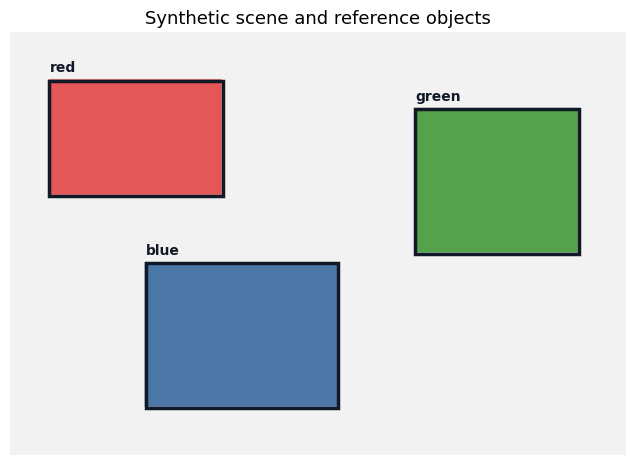

Reference boxes as (center_x, center_y, width, height):
[[0.203 0.25  0.281 0.273]
 [0.375 0.716 0.312 0.341]
 [0.789 0.352 0.266 0.341]]


In [2]:
image_height, image_width = 220, 320
image = np.full((image_height, image_width, 3), 242, dtype=np.uint8)

# Objects are defined as (x_min, y_min, x_max, y_max), in pixels.
objects = [
    ("red", (20, 25, 110, 85)),
    ("blue", (70, 120, 170, 195)),
    ("green", (210, 40, 295, 115)),
]

for name, (x1, y1, x2, y2) in objects:
    rgb_color = {
        "red": (228, 87, 86),
        "blue": (76, 120, 168),
        "green": (84, 162, 75),
    }[name]
    image[y1:y2, x1:x2] = rgb_color

def xyxy_to_normalized_cxcywh(box, image_width, image_height):
    x1, y1, x2, y2 = box
    return np.array([
        ((x1 + x2) / 2) / image_width,
        ((y1 + y2) / 2) / image_height,
        (x2 - x1) / image_width,
        (y2 - y1) / image_height,
    ], dtype=np.float64)

target_classes = np.array([0, 1, 2])
target_boxes = np.vstack([
    xyxy_to_normalized_cxcywh(box, image_width, image_height)
    for _, box in objects
])

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.imshow(image)
for name, (x1, y1, x2, y2) in objects:
    ax.add_patch(Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        fill=False, linewidth=2.5, edgecolor="#111827"
    ))
    ax.text(x1, y1 - 5, name, color="#111827", weight="bold")
ax.set_title("Synthetic scene and reference objects")
ax.axis("off")
plt.show()

print("Reference boxes as (center_x, center_y, width, height):")
print(target_boxes)

## 2. Two-dimensional sinusoidal positional encoding

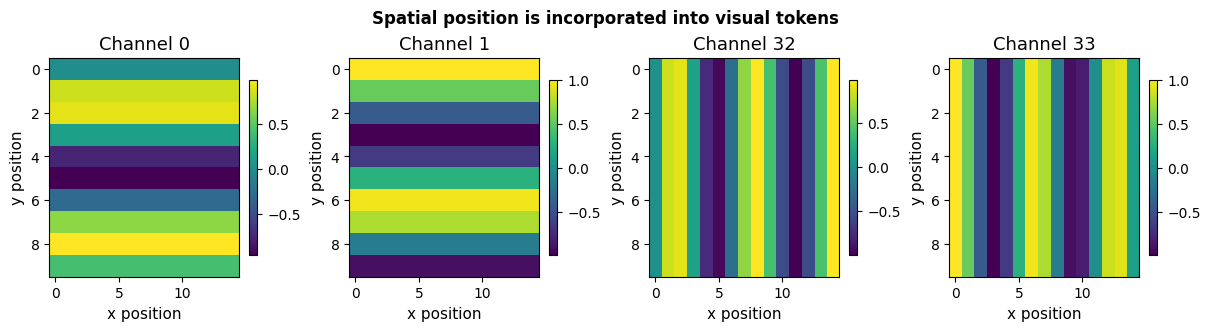

Positional map: (10, 15, 64)
Sequence passed to the Transformer: (150, 64)


In [3]:
def positional_encoding_2d(map_height, map_width, d_model):
    """Create separate sinusoidal encodings for the vertical and horizontal axes."""
    if d_model % 4 != 0:
        raise ValueError("d_model must be divisible by 4")

    half = d_model // 2
    encoding = np.zeros((map_height, map_width, d_model), dtype=np.float64)
    frequencies = np.exp(
        np.arange(0, half, 2) * (-np.log(10000.0) / half)
    )

    y_positions = np.arange(map_height)[:, None, None]
    x_positions = np.arange(map_width)[None, :, None]

    encoding[:, :, 0:half:2] = np.sin(y_positions * frequencies)
    encoding[:, :, 1:half:2] = np.cos(y_positions * frequencies)
    encoding[:, :, half::2] = np.sin(x_positions * frequencies)
    encoding[:, :, half + 1::2] = np.cos(x_positions * frequencies)
    return encoding

positional_encoding = positional_encoding_2d(10, 15, 64)

fig, axes = plt.subplots(1, 4, figsize=(12, 3.2), constrained_layout=True)
for axis, channel in zip(axes, [0, 1, 32, 33]):
    heatmap = axis.imshow(positional_encoding[:, :, channel], cmap="viridis", aspect="auto")
    axis.set_title(f"Channel {channel}")
    axis.set_xlabel("x position")
    axis.set_ylabel("y position")
    fig.colorbar(heatmap, ax=axis, fraction=0.046)
fig.suptitle("Spatial position is incorporated into visual tokens", weight="bold")
plt.show()

print(f"Positional map: {positional_encoding.shape}")
print(f"Sequence passed to the Transformer: {(10 * 15, 64)}")

## 3. DETR architecture flow

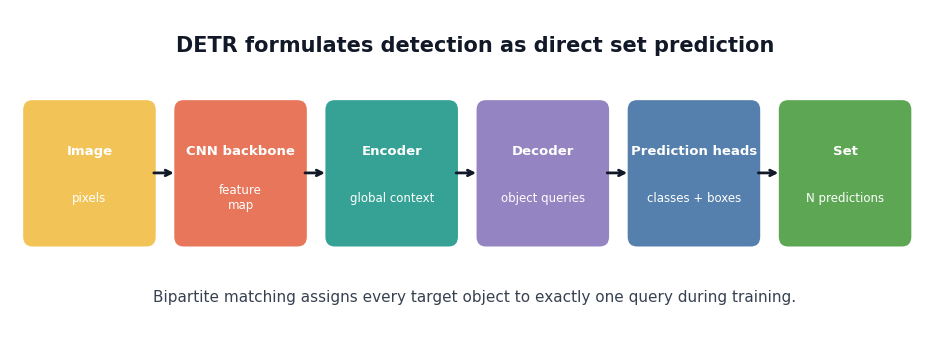

In [4]:
stages = [
    ("Image", "pixels"),
    ("CNN backbone", "feature\nmap"),
    ("Encoder", "global context"),
    ("Decoder", "object queries"),
    ("Prediction heads", "classes + boxes"),
    ("Set", "N predictions"),
]
stage_colors = ["#F2C14E", "#E76F51", "#2A9D8F", "#8E7DBE", "#4C78A8", "#54A24B"]

fig, ax = plt.subplots(figsize=(12, 4.2))
ax.set_xlim(0, 12)
ax.set_ylim(0, 4)
ax.axis("off")

for i, ((title, subtitle), color) in enumerate(zip(stages, stage_colors)):
    x = 0.25 + i * 1.95
    box = FancyBboxPatch(
        (x, 1.15), 1.55, 1.65,
        boxstyle="round,pad=0.08,rounding_size=0.12",
        facecolor=color, edgecolor="none", alpha=0.95
    )
    ax.add_patch(box)
    ax.text(x + 0.775, 2.25, title, ha="center", va="center", weight="bold", color="white", fontsize=9.5)
    ax.text(x + 0.775, 1.67, subtitle, ha="center", va="center", fontsize=8.5, color="white", wrap=True)
    if i < len(stages) - 1:
        ax.annotate(
            "", xy=(x + 1.9, 1.98), xytext=(x + 1.57, 1.98),
            arrowprops=dict(arrowstyle="->", linewidth=2, color="#111827")
        )

ax.text(
    6, 3.55,
    "DETR formulates detection as direct set prediction",
    ha="center", va="center", fontsize=15, weight="bold", color="#111827"
)
ax.text(
    6, 0.45,
    "Bipartite matching assigns every target object to exactly one query during training.",
    ha="center", va="center", fontsize=11, color="#374151"
)
plt.show()

## 4. Simulated object-query outputs

In [5]:
class_names = np.array(["red", "blue", "green", "no object"])

# Each row represents one object query.
# The first three entries are class probabilities; the last is "no object".
probabilities = np.array([
    [0.94, 0.02, 0.02, 0.02],
    [0.83, 0.04, 0.03, 0.10],
    [0.02, 0.94, 0.02, 0.02],
    [0.06, 0.72, 0.04, 0.18],
    [0.01, 0.02, 0.95, 0.02],
    [0.12, 0.10, 0.15, 0.63],
    [0.08, 0.05, 0.07, 0.80],
    [0.10, 0.08, 0.09, 0.73],
], dtype=np.float64)

predicted_boxes = np.array([
    [0.205, 0.260, 0.290, 0.280],
    [0.230, 0.270, 0.320, 0.300],
    [0.380, 0.720, 0.310, 0.340],
    [0.400, 0.690, 0.370, 0.320],
    [0.790, 0.350, 0.270, 0.340],
    [0.520, 0.400, 0.150, 0.200],
    [0.600, 0.800, 0.200, 0.150],
    [0.100, 0.800, 0.150, 0.150],
], dtype=np.float64)

for i, (probs, box) in enumerate(zip(probabilities, predicted_boxes)):
    predicted_class = class_names[np.argmax(probs)]
    print(f"query {i}: class={predicted_class:9s} confidence={probs.max():.2f} box={box}")

query 0: class=red       confidence=0.94 box=[0.205 0.26  0.29  0.28 ]
query 1: class=red       confidence=0.83 box=[0.23 0.27 0.32 0.3 ]
query 2: class=blue      confidence=0.94 box=[0.38 0.72 0.31 0.34]
query 3: class=blue      confidence=0.72 box=[0.4  0.69 0.37 0.32]
query 4: class=green     confidence=0.95 box=[0.79 0.35 0.27 0.34]
query 5: class=no object confidence=0.63 box=[0.52 0.4  0.15 0.2 ]
query 6: class=no object confidence=0.80 box=[0.6  0.8  0.2  0.15]
query 7: class=no object confidence=0.73 box=[0.1  0.8  0.15 0.15]


## 5. Bipartite matching with the Hungarian algorithm

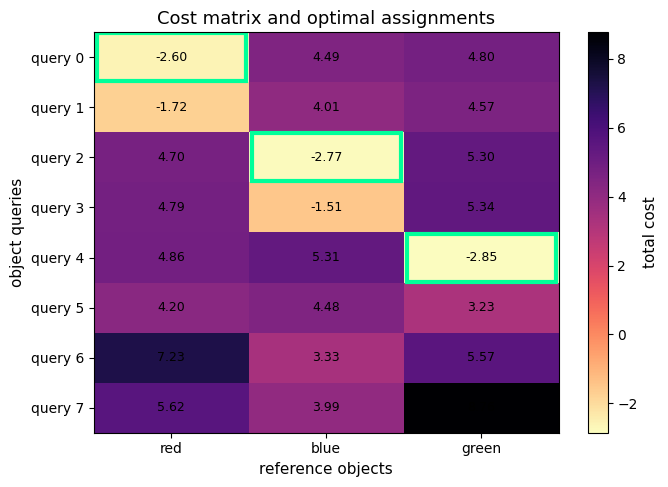

Selected assignments:
query 0 → red object | cost=-2.605
query 2 → blue object | cost=-2.768
query 4 → green object | cost=-2.849


In [6]:
def cxcywh_to_xyxy(boxes):
    cx, cy, width, height = np.moveaxis(np.asarray(boxes), -1, 0)
    return np.stack([cx - width / 2, cy - height / 2, cx + width / 2, cy + height / 2], axis=-1)

def box_area_xyxy(boxes):
    box_width = np.clip(boxes[..., 2] - boxes[..., 0], 0, None)
    box_height = np.clip(boxes[..., 3] - boxes[..., 1], 0, None)
    return box_width * box_height

def pairwise_giou(boxes_a, boxes_b):
    """Calculate GIoU for every pair from two sets of boxes."""
    a = cxcywh_to_xyxy(boxes_a)[:, None, :]
    b = cxcywh_to_xyxy(boxes_b)[None, :, :]

    intersection_min = np.maximum(a[..., :2], b[..., :2])
    intersection_max = np.minimum(a[..., 2:], b[..., 2:])
    intersection_wh = np.clip(intersection_max - intersection_min, 0, None)
    intersection = intersection_wh[..., 0] * intersection_wh[..., 1]

    area_a = box_area_xyxy(a)
    area_b = box_area_xyxy(b)
    union = area_a + area_b - intersection
    iou = intersection / np.clip(union, 1e-9, None)

    enclosing_min = np.minimum(a[..., :2], b[..., :2])
    enclosing_max = np.maximum(a[..., 2:], b[..., 2:])
    enclosing_wh = np.clip(enclosing_max - enclosing_min, 0, None)
    enclosing_area = enclosing_wh[..., 0] * enclosing_wh[..., 1]
    giou = iou - (enclosing_area - union) / np.clip(enclosing_area, 1e-9, None)
    return giou

lambda_l1 = 5.0
lambda_giou = 2.0

class_cost = -probabilities[:, target_classes]
l1_cost = np.abs(predicted_boxes[:, None, :] - target_boxes[None, :, :]).sum(axis=-1)
giou_cost = -pairwise_giou(predicted_boxes, target_boxes)
cost_matrix = class_cost + lambda_l1 * l1_cost + lambda_giou * giou_cost

matched_queries, matched_objects = linear_sum_assignment(cost_matrix)

fig, ax = plt.subplots(figsize=(7.5, 5.2))
heatmap = ax.imshow(cost_matrix, cmap="magma_r", aspect="auto")
for i in range(cost_matrix.shape[0]):
    for j in range(cost_matrix.shape[1]):
        ax.text(j, i, f"{cost_matrix[i, j]:.2f}", ha="center", va="center", fontsize=9)
for query, target in zip(matched_queries, matched_objects):
    ax.add_patch(Rectangle((target - 0.48, query - 0.48), 0.96, 0.96, fill=False, edgecolor="#00FF99", linewidth=3))
ax.set_xticks(range(len(objects)), [name for name, _ in objects])
ax.set_yticks(range(len(predicted_boxes)), [f"query {i}" for i in range(len(predicted_boxes))])
ax.set_xlabel("reference objects")
ax.set_ylabel("object queries")
ax.set_title("Cost matrix and optimal assignments")
fig.colorbar(heatmap, ax=ax, label="total cost")
plt.show()

print("Selected assignments:")
for query, target in zip(matched_queries, matched_objects):
    print(f"query {query} → {objects[target][0]} object | cost={cost_matrix[query, target]:.3f}")

## 6. Loss-function components

In [7]:
no_object_index = 3
class_targets = np.full(len(predicted_boxes), no_object_index, dtype=int)
class_targets[matched_queries] = target_classes[matched_objects]

# The "no object" class receives a smaller weight, as in DETR training.
class_weights = np.ones(len(predicted_boxes), dtype=np.float64)
class_weights[class_targets == no_object_index] = 0.1
cross_entropy_losses = -np.log(np.clip(probabilities[np.arange(len(probabilities)), class_targets], 1e-9, 1.0))
classification_loss = np.average(cross_entropy_losses, weights=class_weights)

matched_predictions = predicted_boxes[matched_queries]
matched_targets = target_boxes[matched_objects]
l1_loss = np.abs(matched_predictions - matched_targets).sum(axis=-1).mean()
diagonal_giou = np.diag(pairwise_giou(matched_predictions, matched_targets))
giou_loss = (1.0 - diagonal_giou).mean()
total_loss = classification_loss + lambda_l1 * l1_loss + lambda_giou * giou_loss

print(f"Classification loss: {classification_loss:.4f}")
print(f"L1 loss:             {l1_loss:.4f}")
print(f"GIoU loss:           {giou_loss:.4f}")
print(f"Total loss:          {total_loss:.4f}")
print(f"Matched queries:     {len(matched_queries)}")
print(f"No-object queries:   {(class_targets == no_object_index).sum()}")

Classification loss: 0.1934
L1 loss:             0.0163
GIoU loss:           0.0606
Total loss:          0.3961
Matched queries:     3
No-object queries:   5


## 7. One-to-one assignment result

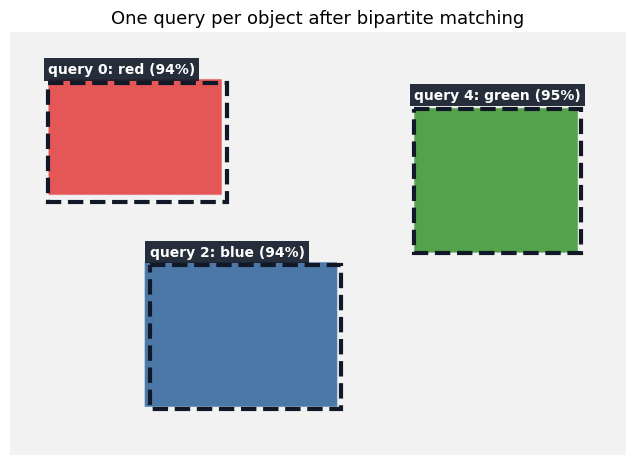

In [8]:
def normalized_box_to_pixels(box, image_width, image_height):
    cx, cy, width, height = box
    x1 = (cx - width / 2) * image_width
    y1 = (cy - height / 2) * image_height
    return x1, y1, width * image_width, height * image_height

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.imshow(image)

for query, target in zip(matched_queries, matched_objects):
    class_name = objects[target][0]
    x, y, width, height = normalized_box_to_pixels(predicted_boxes[query], image_width, image_height)
    ax.add_patch(Rectangle(
        (x, y), width, height,
        fill=False, linewidth=3, edgecolor="#111827", linestyle="--"
    ))
    confidence = probabilities[query, target_classes[target]]
    ax.text(
        x, max(12, y - 5), f"query {query}: {class_name} ({confidence:.0%})",
        color="white", weight="bold",
        bbox=dict(facecolor="#111827", alpha=0.9, pad=3, edgecolor="none")
    )

ax.set_title("One query per object after bipartite matching")
ax.axis("off")
plt.show()

## Takeaways

- DETR produces a **fixed-size set of predictions** instead of independent proposals followed by NMS.
- Positional encoding preserves spatial location after a feature map is converted into a sequence.
- The Hungarian algorithm finds the minimum-cost global assignment between queries and target objects.
- Every object supervises exactly one query; all remaining queries receive the **no object** target.
- The loss combines classification, L1 distance, and GIoU to balance category prediction and localization.

Reference: [End-to-End Object Detection with Transformers](https://arxiv.org/abs/2005.12872), Carion et al. (2020).